# Compose Figure 4 with UMAP panel (e)

Stitches `Figure4.pdf` + `umap_by_coarse_group.pdf` into a single multi-panel PDF.
- Vectors preserved (no rasterization).
- Figure 4 is clipped to its content region.
- UMAP suptitle **and** above-plot column labels are clipped out.
- Below the plots: model names, ARI/NMI on a single line, and a color legend for the coarse groups.
- Panel `e` label is regular weight.

In [ ]:
# !pip install --quiet pymupdf

In [1]:
import os
import fitz  # PyMuPDF

FIG_DIR = "/hpc/group/jilab/tc459/MorphPT/results/figures/feature_space_core500_emb_2p5x_fixedcolor"
FIG4_PDF = os.path.join(FIG_DIR, "Figure4.pdf")
UMAP_PDF = os.path.join(FIG_DIR, "umap_by_coarse_group.pdf")
OUT_PDF  = os.path.join(FIG_DIR, "Figure4_with_UMAP.pdf")

In [2]:
# ----- Layout parameters -----

FIG4_CONTENT = fitz.Rect(0, 0, 903, 531)
UMAP_PLOTS_CLIP = fitz.Rect(0, 62, 900, 312)

MODEL_CENTERS_SRC_X = {
    "MorphPT":       151.2,
    "Frozen DINOv3": 450.0,
    "Frozen SimCLR": 748.8,
}

METRICS = {
    "MorphPT":       {"ari": 0.461, "nmi": 0.550},
    "Frozen DINOv3": {"ari": 0.106, "nmi": 0.148},
    "Frozen SimCLR": {"ari": 0.041, "nmi": 0.052},
}

COARSE_COLORS = {
    "Cancer":          "#9467BD",
    "Lymphoid":        "#2CA02C",
    "Neuroglial":      "#AEC7E8",
    "Stem_Progenitor": "#BCBD22",
    "Stromal":         "#E377C2",
    "Tissue_Vascular": "#D62728",
}

# ---- Spacing ----
GAP_LABEL             = 14   # vertical band above plots where the 'e' sits
LABEL_PADDING_BELOW   = 3    # gap between 'e' baseline and plot top
GAP_PLOTS_TO_NAMES    = 6
GAP_NAMES_TO_METRICS  = 4
GAP_METRICS_TO_LEGEND = 14
BOTTOM_PAD            = 8

# ---- Fonts ----
PANEL_LABEL          = "e"
PANEL_LABEL_FONT     = "helvetica"
PANEL_LABEL_FONTSIZE = 22
PANEL_LABEL_X        = 6

MODEL_NAME_FONT      = "helvetica"
MODEL_NAME_FONTSIZE  = 16

METRIC_FONT          = "helvetica"
METRIC_FONTSIZE      = 12
METRIC_SEP           = "   "   # separator between ARI and NMI on the same line

LEGEND_FONT          = "helvetica"
LEGEND_FONTSIZE      = 13
LEGEND_SQ            = 12
LEGEND_SQ_TO_LABEL   = 4
LEGEND_INTER_GAP     = 20

In [3]:
# ----- Helpers -----
def hex_to_rgb01(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))

def text_w(s, font, size):
    return fitz.get_text_length(s, fontname=font, fontsize=size)

In [4]:
# ----- Compose -----
fig4_doc = fitz.open(FIG4_PDF)
umap_doc = fitz.open(UMAP_PDF)

W = FIG4_CONTENT.width
H_FIG = FIG4_CONTENT.height
scale = W / UMAP_PLOTS_CLIP.width
plots_h = UMAP_PLOTS_CLIP.height * scale

# Below-plot block: name line + one metrics line + legend row
below_h = (
    GAP_PLOTS_TO_NAMES + MODEL_NAME_FONTSIZE
    + GAP_NAMES_TO_METRICS + METRIC_FONTSIZE
    + GAP_METRICS_TO_LEGEND + max(LEGEND_FONTSIZE, LEGEND_SQ)
    + BOTTOM_PAD
)
total_h = H_FIG + GAP_LABEL + plots_h + below_h

out = fitz.open()
page = out.new_page(width=W, height=total_h)

# --- Figure 4 ---
page.show_pdf_page(fitz.Rect(0, 0, W, H_FIG), fig4_doc, 0, clip=FIG4_CONTENT)

# --- UMAP plots ---
y_plots_top = H_FIG + GAP_LABEL
y_plots_bot = y_plots_top + plots_h
page.show_pdf_page(
    fitz.Rect(0, y_plots_top, W, y_plots_bot),
    umap_doc, 0, clip=UMAP_PLOTS_CLIP,
)

# --- 'e' label (anchored just above the plots) ---
page.insert_text(
    fitz.Point(PANEL_LABEL_X, y_plots_top - LABEL_PADDING_BELOW),
    PANEL_LABEL,
    fontname=PANEL_LABEL_FONT, fontsize=PANEL_LABEL_FONTSIZE,
)

# --- Model names ---
y_name_baseline = y_plots_bot + GAP_PLOTS_TO_NAMES + MODEL_NAME_FONTSIZE
for name, src_cx in MODEL_CENTERS_SRC_X.items():
    dst_cx = src_cx * scale
    tw = text_w(name, MODEL_NAME_FONT, MODEL_NAME_FONTSIZE)
    page.insert_text(
        fitz.Point(dst_cx - tw / 2, y_name_baseline),
        name, fontname=MODEL_NAME_FONT, fontsize=MODEL_NAME_FONTSIZE,
    )

# --- ARI / NMI on a single line, centered under each name ---
y_metric_baseline = y_name_baseline + GAP_NAMES_TO_METRICS + METRIC_FONTSIZE
for name, src_cx in MODEL_CENTERS_SRC_X.items():
    dst_cx = src_cx * scale
    line = f"ARI = {METRICS[name]['ari']:.3f}{METRIC_SEP}NMI = {METRICS[name]['nmi']:.3f}"
    tw = text_w(line, METRIC_FONT, METRIC_FONTSIZE)
    page.insert_text(
        fitz.Point(dst_cx - tw / 2, y_metric_baseline),
        line, fontname=METRIC_FONT, fontsize=METRIC_FONTSIZE,
    )

# --- Color legend (single row, centered) ---
items = [(l, c, text_w(l, LEGEND_FONT, LEGEND_FONTSIZE)) for l, c in COARSE_COLORS.items()]
row_w = sum(LEGEND_SQ + LEGEND_SQ_TO_LABEL + lw for _, _, lw in items) + \
        LEGEND_INTER_GAP * (len(items) - 1)
x_cursor = (W - row_w) / 2
y_legend_top = y_metric_baseline + GAP_METRICS_TO_LEGEND
sq_y_top = y_legend_top + (LEGEND_FONTSIZE - LEGEND_SQ) / 2 + 1
label_baseline = y_legend_top + LEGEND_FONTSIZE

for label, hexcol, lw in items:
    rgb = hex_to_rgb01(hexcol)
    page.draw_rect(
        fitz.Rect(x_cursor, sq_y_top, x_cursor + LEGEND_SQ, sq_y_top + LEGEND_SQ),
        color=rgb, fill=rgb, width=0,
    )
    page.insert_text(
        fitz.Point(x_cursor + LEGEND_SQ + LEGEND_SQ_TO_LABEL, label_baseline),
        label, fontname=LEGEND_FONT, fontsize=LEGEND_FONTSIZE,
    )
    x_cursor += LEGEND_SQ + LEGEND_SQ_TO_LABEL + lw + LEGEND_INTER_GAP

out.save(OUT_PDF)
print(f"Wrote {OUT_PDF}")
print(f"Page size: {W:.0f} x {total_h:.0f} pt  ({W/72:.2f} x {total_h/72:.2f} in)")

Wrote /hpc/group/jilab/tc459/MorphPT/results/figures/feature_space_core500_emb_2p5x_fixedcolor/Figure4_with_UMAP.pdf
Page size: 903 x 869 pt  (12.54 x 12.07 in)


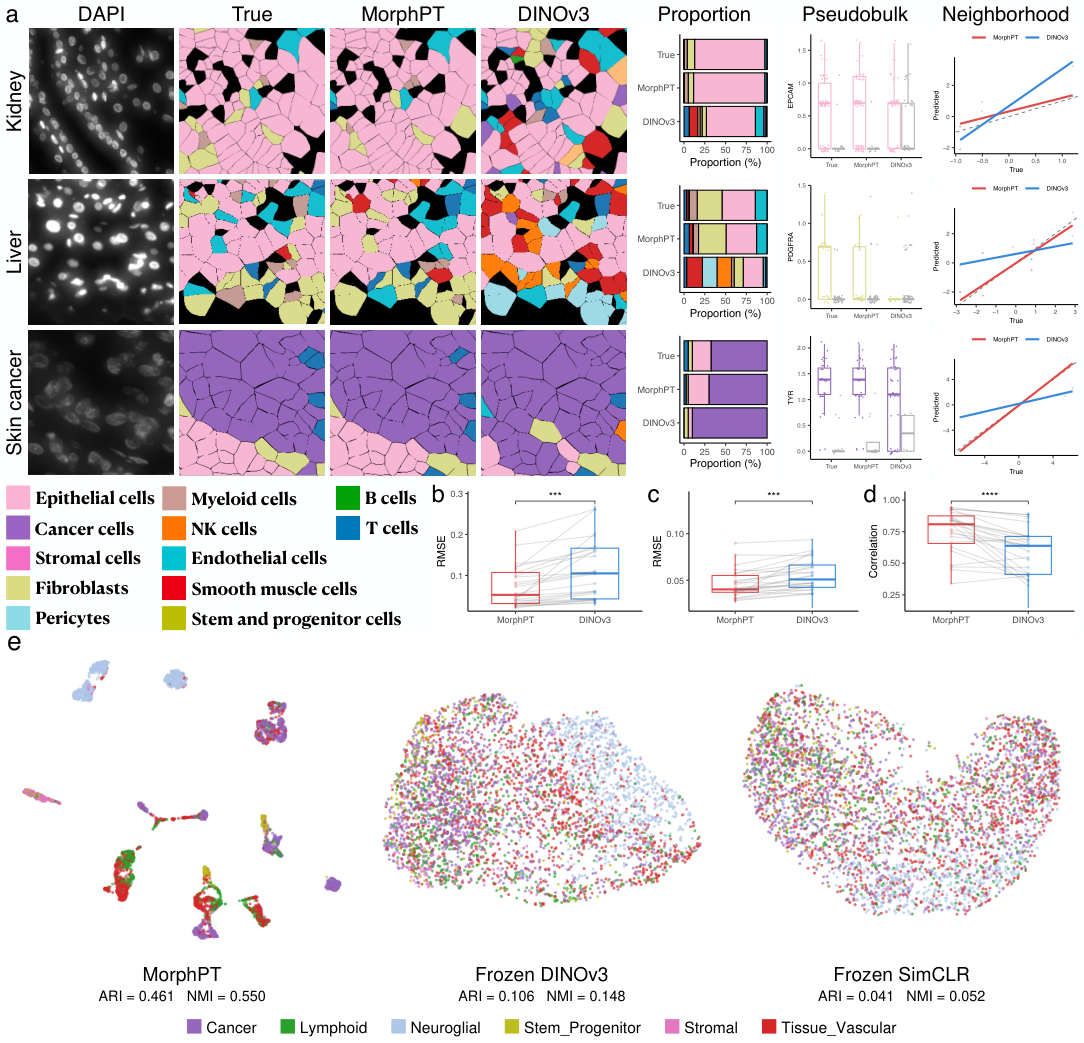

In [5]:
from IPython.display import Image, display
doc = fitz.open(OUT_PDF)
pix = doc[0].get_pixmap(matrix=fitz.Matrix(1.2, 1.2))
display(Image(data=pix.tobytes("png")))